# Assignment #2 - Convolutional Neural Networks

<font color="red"> <b> Due: Mar 6 (Friday) 11:00 pm </b> </font>

<font color="blue"> Abeoseh Flemister </font>

# Introduction

[General introduction of this writing assignment] Describe the objective of this assignment. You can briefly state how you accompilsh it.

In [ ]:
from keras.applications.resnet50 import ResNet50
# import torchvision.transforms as transforms
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
print("TF version:", tf.__version__)

import tensorflow_datasets as tfds
import tensorflow as tf

import matplotlib.pyplot as plt
import numpy as np

import keras_tuner

import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'

import segmentation_models as sm 

import tensorflow_addons as tfa

TF version: 2.20.0
Segmentation Models: using `tf.keras` framework.


# Data

**Introduce** your image data and **visualize** them. Describe your observations about the data.
Please check some of visualizations in the labs (you can explore more for others).

**Please do not use the data we practiced in the lab. Also, make sure to play with about 1000 samples. You can scale down or up the image if need.**


In [2]:
VOCDetection_dataset, VOCDetection_info = tfds.load('voc/2012',with_info=True)

In [9]:
print(VOCDetection_info)

tfds.core.DatasetInfo(
    name='voc',
    full_name='voc/2012/5.0.0',
    description="""
    This dataset contains the data from the PASCAL Visual Object Classes Challenge,
    corresponding to the Classification and Detection competitions.
    
    In the Classification competition, the goal is to predict the set of labels
    contained in the image, while in the Detection competition the goal is to
    predict the bounding box and label of each individual object.
    annotations.
    """,
    config_description="""
    This dataset contains the data from the PASCAL Visual Object Classes Challenge
    2012, a.k.a. VOC2012.
    
    A total of 11540 images are included in this dataset, where each image
    contains a set of objects, out of 20 different classes, making a total of
    27450 annotated objects.
    
    """,
    homepage='http://host.robots.ox.ac.uk/pascal/VOC/voc2012/',
    data_dir='C:\\Users\\brean\\tensorflow_datasets\\voc\\2012\\5.0.0',
    file_format=tfrecord,
   

In [3]:
class_labels = VOCDetection_info.features["labels"].names
class_labels

['aeroplane',
 'bicycle',
 'bird',
 'boat',
 'bottle',
 'bus',
 'car',
 'cat',
 'chair',
 'cow',
 'diningtable',
 'dog',
 'horse',
 'motorbike',
 'person',
 'pottedplant',
 'sheep',
 'sofa',
 'train',
 'tvmonitor']

I am multi-hot encoding the labels since each image contains multiple labels. 

The original image size is 500, 333, 3 but I am resizing it to be 128, 128, 3. Since the images contain multiple classes with some of them (such as bottles) being small, I don't want to make the images too pixelated since it would make it hard to classify the images. 

In [ ]:
def resize(input_image):
    input_image = tf.image.resize(input_image, (128, 128), method="nearest")

    return input_image

def normalize(input_image):
    input_image = tf.cast(input_image, tf.float32) / 255.0

    return input_image

def load_image_train(datapoint):
    input_image = datapoint["image"]
    input_label = datapoint["labels"]
    multi_hot = tf.reduce_sum(tf.one_hot(input_label, 20),axis=0)
    input_image = resize(input_image)
    input_image = normalize(input_image)
    
    return input_image, multi_hot


def load_image_test(datapoint):
    input_image = datapoint["image"]
    input_label = datapoint["labels"] ## the test dataset doesn't have labels
    multi_hot = tf.reduce_sum(tf.one_hot(input_label, 20),axis=0)
    input_image = resize(input_image)
    input_image = normalize(input_image)

    return input_image, multi_hot



In [5]:
def show_img(x, title="", bot=""): ## bot is bottom
    plt.imshow(x)
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.xlabel(bot)

In [88]:
for example in VOCDetection_dataset["test"].take(10):
    print(example.keys())
    print(example["labels"],"|" ,example["labels_no_difficult"])
    print(example["image"].shape)
    print(type(example["image"]))
    print("-------------")



dict_keys(['image', 'image/filename', 'labels', 'labels_no_difficult', 'objects'])
tf.Tensor([], shape=(0,), dtype=int64) | tf.Tensor([], shape=(0,), dtype=int64)
(500, 333, 3)
<class 'tensorflow.python.framework.ops.EagerTensor'>
-------------
dict_keys(['image', 'image/filename', 'labels', 'labels_no_difficult', 'objects'])
tf.Tensor([], shape=(0,), dtype=int64) | tf.Tensor([], shape=(0,), dtype=int64)
(334, 500, 3)
<class 'tensorflow.python.framework.ops.EagerTensor'>
-------------
dict_keys(['image', 'image/filename', 'labels', 'labels_no_difficult', 'objects'])
tf.Tensor([], shape=(0,), dtype=int64) | tf.Tensor([], shape=(0,), dtype=int64)
(282, 500, 3)
<class 'tensorflow.python.framework.ops.EagerTensor'>
-------------
dict_keys(['image', 'image/filename', 'labels', 'labels_no_difficult', 'objects'])
tf.Tensor([], shape=(0,), dtype=int64) | tf.Tensor([], shape=(0,), dtype=int64)
(375, 500, 3)
<class 'tensorflow.python.framework.ops.EagerTensor'>
-------------
dict_keys(['image', 

In [71]:
BATCH_SIZE = 64
BUFFER_SIZE = 1000


train_dataset = VOCDetection_dataset["train"].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
# test_dataset = VOCDetection_dataset["test"].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = VOCDetection_dataset["validation"].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)

# train_batches = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
# train_batches = train_batches.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
# validation_batches = validation_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# test_batches = test_dataset.skip(3000).take(669).batch(BATCH_SIZE)



train_batches = train_dataset.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_batches = train_batches.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
validation_batches = validation_dataset.take(3000).batch(BATCH_SIZE)
test_batches = validation_dataset.skip(3000).take(669).batch(BATCH_SIZE)

## 

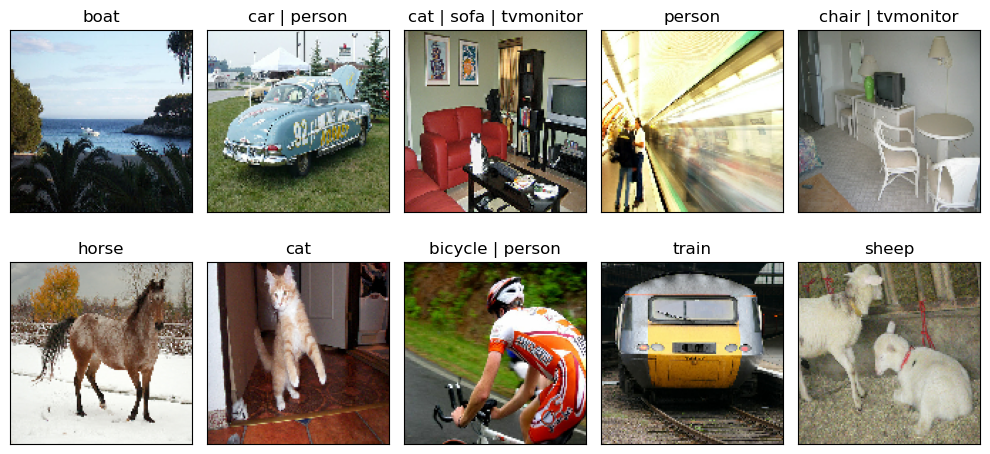

In [72]:
plt.figure(figsize = (10,5))
for i in range(10):
    sample_batch = next(iter(train_batches))
    random_index = np.random.choice(sample_batch[0].shape[0])
    sample_image, sample_label = sample_batch[0][random_index], sample_batch[1][random_index]
    # tf.print(sample_label)
    label_string = " | ".join([class_labels[index] for index in (sample_label.numpy() == 1).nonzero()[0]])
    plt.subplot(2,5,i+1)
    show_img(sample_image, label_string)

plt.tight_layout()

# ResNet-50

To save your computation, we leverage pretrained models. Using transfer learning, we only finetune ResNet-50 for image classification and image segmentation.

Summarize the ResNet-50 model here before start loading it, and then implement the codes that load the base model.


<font color="red"> NOTE: We do not consider comments in the code cell as a proper writing. Make sure explain in a Markdown cell not regardless the comment in the code cell. </font>


# Helper Functions

These are the functions that all parts (classification without augmentation, classification with augmentation, and segmentation) will use. 

In [18]:
def plot_learning(history, title, label: str, metric, val_metric):
    """
      title: graph name
      label: y-axis label
      metric: metric you're plotting
      val_metric: validation metric you're plotting
    """
    plt.plot(history.history[metric], label=metric)
    plt.plot(history.history[val_metric], label=val_metric)
    plt.xlabel('Epoch')
    plt.ylabel(f'{label}')
    plt.title(title)
    plt.legend()
    plt.show()

# Image Classification

Here are checklist items that you should work on:

1. Explain your ResNet-50 based CNN for image classification and implement it.
1. Load your image classification data, and then train the image classifier.
1. Properly search hyperparameters to tune the best performing model (report hyperparameter search process, e.g., cross validation).
1. Visualize and evaluate the performance of your image classification.

Place these items under the following Method and Experiment subsections.


## Method

In [8]:
res_base = ResNet50(include_top=False, weights='imagenet', input_shape = (128,128,3))
res_base.trainable = False


In [9]:
class ResPretrained(keras.Model):
    def __init__(self):
        super().__init__()

        # Bias
        bias = tf.Variable(tf.random.normal([3]), trainable=True, name="bias")

        # Single Sequential model
        self.model = keras.Sequential([
            layers.Input(shape=(128,128,3)),
            layers.Lambda(keras.applications.vgg16.preprocess_input),
            layers.Lambda(lambda x: tf.nn.bias_add(x, bias)),
            res_base,
            layers.Flatten(),
            layers.Dense(256),
            layers.Dropout(0.5),
            layers.Dense(20, activation="sigmoid"),
        ])
        self.model.summary()

    # def call(self, inputs):
    #     return self.model(inputs)

ResPretrainedModel = ResPretrained()
ResPretrainedModel.model.compile(loss = "binary_crossentropy", optimizer="rmsprop", metrics=[tf.keras.metrics.BinaryAccuracy(),tf.keras.metrics.Precision(),tf.keras.metrics.Recall()])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,981,716 (122.00 MB)

 Trainable params: 8,394,004 (32.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

On the output layer I am using sigmoid where for each of the 20 classes I am predicting if the image contains that class. 

First I want to do a random search do determine the best hyperparameters for the model. 

I am tuning:
1. the number of units in the hidden dense layer with possible values of 8, 100, 265
2. 

In [ ]:
def build_model(hp):
    bias = tf.Variable(tf.random.normal([3]), trainable=True, name="bias")

    model = keras.Sequential([
                layers.Input(shape=(128,128,3)),
                layers.Lambda(keras.applications.vgg16.preprocess_input),
                layers.Lambda(lambda x: tf.nn.bias_add(x, bias)),
                res_base,
                layers.Flatten(),
                layers.Dense(hp.Choice('units', [8, 100, 265])),
                layers.Dropout(hp.Choice('rate', [0.2, 0.5, 0.6])),
                layers.Dense(20, activation="sigmoid"),
            ])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate = hp_learning_rate),
                  loss = "binary_crossentropy", 
                  metrics = [tf.keras.metrics.BinaryAccuracy(),tf.keras.metrics.Precision(),tf.keras.metrics.Recall()])
    return model

## Experiments

In [ ]:
tuner = keras_tuner.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5)

tuner.search(train_batches, epochs=5, steps_per_epoch=57,
             validation_data=validation_batches)

best_model = tuner.get_best_models()[0]

Trial 5 Complete [00h 09m 30s]
val_loss: 0.2341948002576828

Best val_loss So Far: 0.2294558584690094
Total elapsed time: 01h 13m 06s


c:\Users\brean\miniconda3\envs\deeplearning\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Now I can see the best values from the random search. These are the values I will use when training the model. 

In [28]:

print(f"Best number of units: {tuner.get_best_hyperparameters()[0].get('units')}")
print(f"Best dropout rate: {tuner.get_best_hyperparameters()[0].get('rate')}")
print(f"Best learning rate: {tuner.get_best_hyperparameters()[0].get('learning_rate')}")

best_model.summary()


Best number of units: 100
Best dropout rate: 0.2
Best learning rate: 0.0001


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     3,276,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,145,554 (115.00 MB)

 Trainable params: 3,278,920 (12.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 3,278,922 (12.51 MB)

I am going to use the best model and train for 20 epochs with 57 steps per an epoch. 
|Best |value |
|---------------------| ----|
|units | 100 |
|dropout rate | 0.2 |
|learning rate | 0.0001 |

In [73]:
Respretrained_History = best_model.fit(train_batches, epochs = 20, steps_per_epoch=57,
                verbose = 1, validation_data=validation_batches)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - binary_accuracy: 0.9248 - loss: 0.2205 - precision: 0.5795 - recall: 0.1315

InvalidArgumentError: Graph execution error:

Detected at node IteratorGetNext defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "c:\Users\brean\miniconda3\envs\deeplearning\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>

  File "c:\Users\brean\miniconda3\envs\deeplearning\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance

  File "c:\Users\brean\miniconda3\envs\deeplearning\Lib\site-packages\ipykernel\kernelapp.py", line 758, in start

  File "c:\Users\brean\miniconda3\envs\deeplearning\Lib\site-packages\tornado\platform\asyncio.py", line 211, in start

  File "c:\Users\brean\miniconda3\envs\deeplearning\Lib\asyncio\base_events.py", line 641, in run_forever

  File "c:\Users\brean\miniconda3\envs\deeplearning\Lib\asyncio\base_events.py", line 1987, in _run_once

  File "c:\Users\brean\miniconda3\envs\deeplearning\Lib\asyncio\events.py", lin

I can see that although the training and validation loss trends down, it doesn't change by much. The maximum is around 0.23 and it goes down to approximately 0.22. Similarly, the training and validation binary accuracy goes from approximately 0.92 to 0.93.

Despite this, the loss was already low and the binary accuracy was already high. 

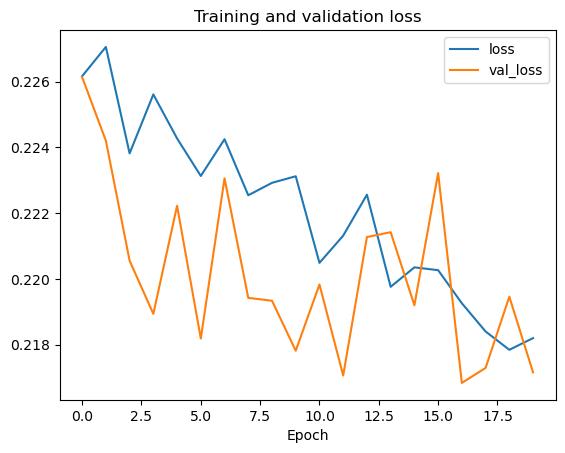

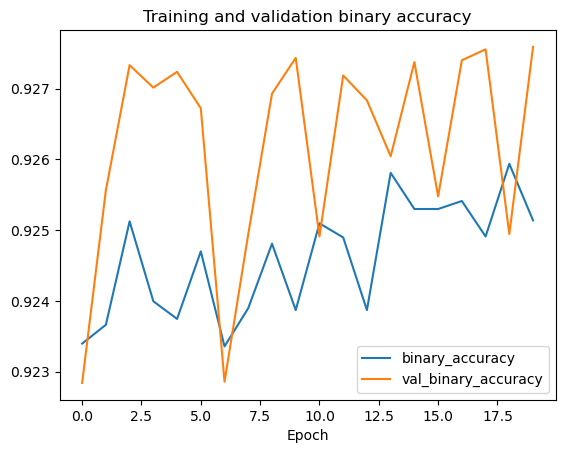

In [ ]:
plot_learning(Respretrained_History, title = "Training and validation loss", label = "", metric = "loss", val_metric= "val_loss")
plot_learning(Respretrained_History, title = "Training and validation binary accuracy", label = "", metric = "binary_accuracy", val_metric= "val_binary_accuracy")

In [ ]:
predictions = best_model.predict(test_batches)

11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 522ms/step


In [66]:
predictions.shape

(669, 20)

Get the indicies of the classes with a greater than 0.2

In [ ]:
indices_per_image = [np.where(p > 0.2)[0] for p in predictions]

[array([], dtype=int64),
 array([ 8, 14], dtype=int64),
 array([ 1, 14], dtype=int64),
 array([ 8, 14, 19], dtype=int64),
 array([14], dtype=int64),
 array([ 4,  8, 10, 14], dtype=int64),
 array([2], dtype=int64),
 array([], dtype=int64),
 array([7], dtype=int64),
 array([ 5,  8, 14], dtype=int64),
 array([ 4, 14], dtype=int64),
 array([14], dtype=int64),
 array([14], dtype=int64),
 array([2], dtype=int64),
 array([2], dtype=int64),
 array([ 8, 14, 19], dtype=int64),
 array([14], dtype=int64),
 array([2, 7], dtype=int64),
 array([14], dtype=int64),
 array([14], dtype=int64),
 array([ 1, 13, 14], dtype=int64),
 array([14], dtype=int64),
 array([], dtype=int64),
 array([14], dtype=int64),
 array([14], dtype=int64),
 array([ 6, 14], dtype=int64),
 array([14], dtype=int64),
 array([ 6, 14], dtype=int64),
 array([14], dtype=int64),
 array([], dtype=int64),
 array([ 7, 14], dtype=int64),
 array([14], dtype=int64),
 array([13, 14], dtype=int64),
 array([14], dtype=int64),
 array([14], dtype=i

In [69]:
test_batches[0]

TypeError: '_BatchDataset' object is not subscriptable

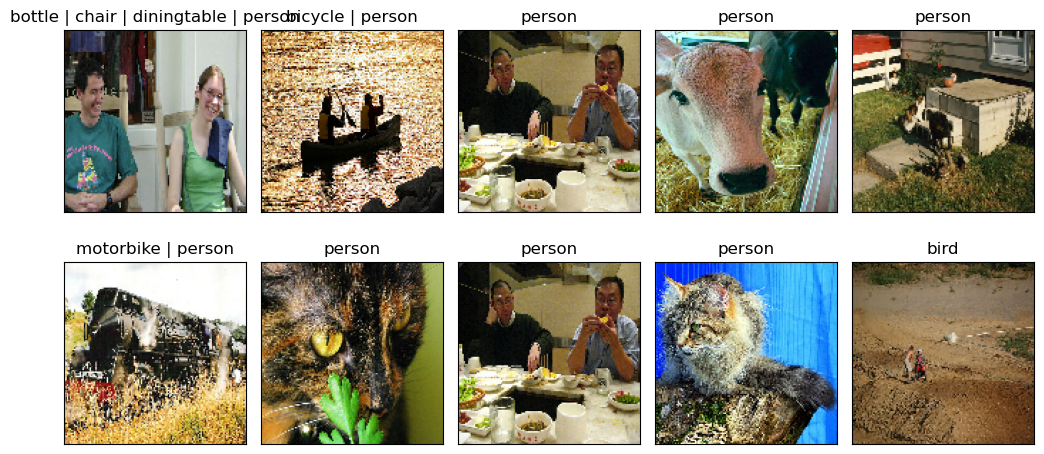

In [55]:
plt.figure(figsize = (10,5))
for i in range(10):
    sample_batch = next(iter(test_batches))
    random_index = np.random.choice(sample_batch[0].shape[0])
    sample_image, sample_label = sample_batch[0][random_index], indices_per_image[random_index]
    # tf.print(sample_label)
    label_string = " | ".join([class_labels[index] for index in sample_label])
    plt.subplot(2,5,i+1)
    show_img(sample_image, label_string)

plt.tight_layout()

In [65]:
sample_batch[0].shape

TensorShape([64, 128, 128, 3])

In [58]:
random_index

6

# Image Augmentation

In this section, you are repeating image classification process but with augmented images for training.
Practice at least two image augmentations and see how much they improve the performance of the model.

I am randomly augmenting half of the images by flipping them left or right, adjusting their contrast by 2 units, and rotating it between 0 and 360 degrees. This will allow me to ensure the model doesn't overfit.

All other than the augmentation, all other functions are stying the same.  

In [ ]:
def resize(input_image):
    return tf.image.resize(input_image, (128, 128), method="nearest")

def normalize(input_image):
    return tf.cast(input_image, tf.float32) / 255.0


def augment(input_image):
    if tf.random.uniform(()) > 0.5:
        # Random flipping of the image and mask
        input_image = tf.image.flip_left_right(input_image)
        contrast_factor = 2.0
        input_image = tf.image.adjust_contrast(input_image, contrast_factor)
        ## rotate the image between 0 and 2pi radians (0 and 360 degrees)
        # input_image = tfa.image.rotate(input_image, tf.random.uniform(shape = [], minval = 0, maxval=2*np.pi))

    return input_image


def load_image_train(datapoint):
    input_image = datapoint["image"]
    input_label = datapoint["labels"]
    multi_hot = tf.reduce_sum(tf.one_hot(input_label, 20),axis=0)
    input_image = resize(input_image)
    input_image = normalize(input_image)
    
    return input_image, multi_hot


def load_image_test(datapoint):
    input_image = datapoint["image"]
    input_label = datapoint["labels"] ## the test dataset doesn't have labels

    input_image = resize(input_image)
    input_image = normalize(input_image)

    return input_image, input_label


## Method

I am going to standardize the image size to be 128 x 128 x 3. 

The augmenting will be done with random flipping and changing the contrast to ensure I don't overfit on the training data. 

## Experiments

# Image Segmentation

Reviewing the lab practice, create a ResNet-50 based image segmentation model.
You are using the same dataset to replicate the results but with another model.  
Discuss your implementation details.



In [ ]:
seg_ds, info = tfds.load(
    "voc/2012_segmentation",
    split="train",
    with_info=True
)


In [ ]:
model = sm.Unet('resnet50', 
                encoder_weights='imagenet', # Use pre-trained weights
                classes=1,                 # Number of classes
                activation='sigmoid',
                input_shape = (128,128,3=)) 



In [ ]:
## maybe x = image y = mask ????

unetHistory = unet_model.fit(train_batches, epochs = 20, steps_per_epoch=57, validation_data=validation_batches)

In [ ]:
def display(display_list: list): ## bot is bottom
    plt.figure(figsize = (15,15))
    title = ["Input Image", "True Mask", "Predicted Mask"]
    for i in range(len(display_list)):
        plt.subplot(1,len(display_list),i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis("off")

    plt.show()

In [ ]:
train_dataset = VOCDetection_dataset["train"].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = VOCDetection_dataset["test"].map(load_image_test, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset

## Method

## Experiments

# Conclusions

Discuss the challenges or somethat that you learned.
If you have any suggestion about the assignment, you can write about it.

# References

List your references to complete your assignment. Use a proper reference style (APA, MLA, etc.).

## Grading

As of size of images, please do not submit your data. Instead, provide instructions to download them along with the link. Your notebook is supposed to run well after downloading to the working directory.

**Note: this is a WRITING assignment. Proper writing is REQUIRED. Comments are not considered as writing.**


Points | | Description
--|--|:--
5 | Introduction  
10 | Data |
 | 5| description
 | 5| plots for understanding or analysis
30 | Image Classification |
 | 10| Explanation of deep network architecture and implementation
 | 5|  Hyperparameter search
 | 10| Visualization, evaluation of results
 | 5 | Analysis and discussion
15 | Image Augmentation |
 | 5| Explanation of deep network architecture and implementation
 | 5| Visualization, evaluation of results
 | 5 | Analysis and discussion
30 | Image Segmentation |
 | 10| Explanation of deep network architecture and implementation
 | 5|  Hyperparameter search
 | 10| Visualization, evaluation of results
 | 5 | Analysis and discussion
5 | Conclusions
5 | References